# ARTI404 – Image Processing
## Lab 4: Intensity Transformations and Filtering – Spatial Domain
### Name: Abdullah Alnaji
### ID: 2240007157

In [1]:
import os
import cv2
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from skimage import data, img_as_float, exposure
from skimage.exposure import match_histograms

os.makedirs('images', exist_ok=True)
%matplotlib inline

# Section 3 – Procedural Steps
## Task 1: Thresholding


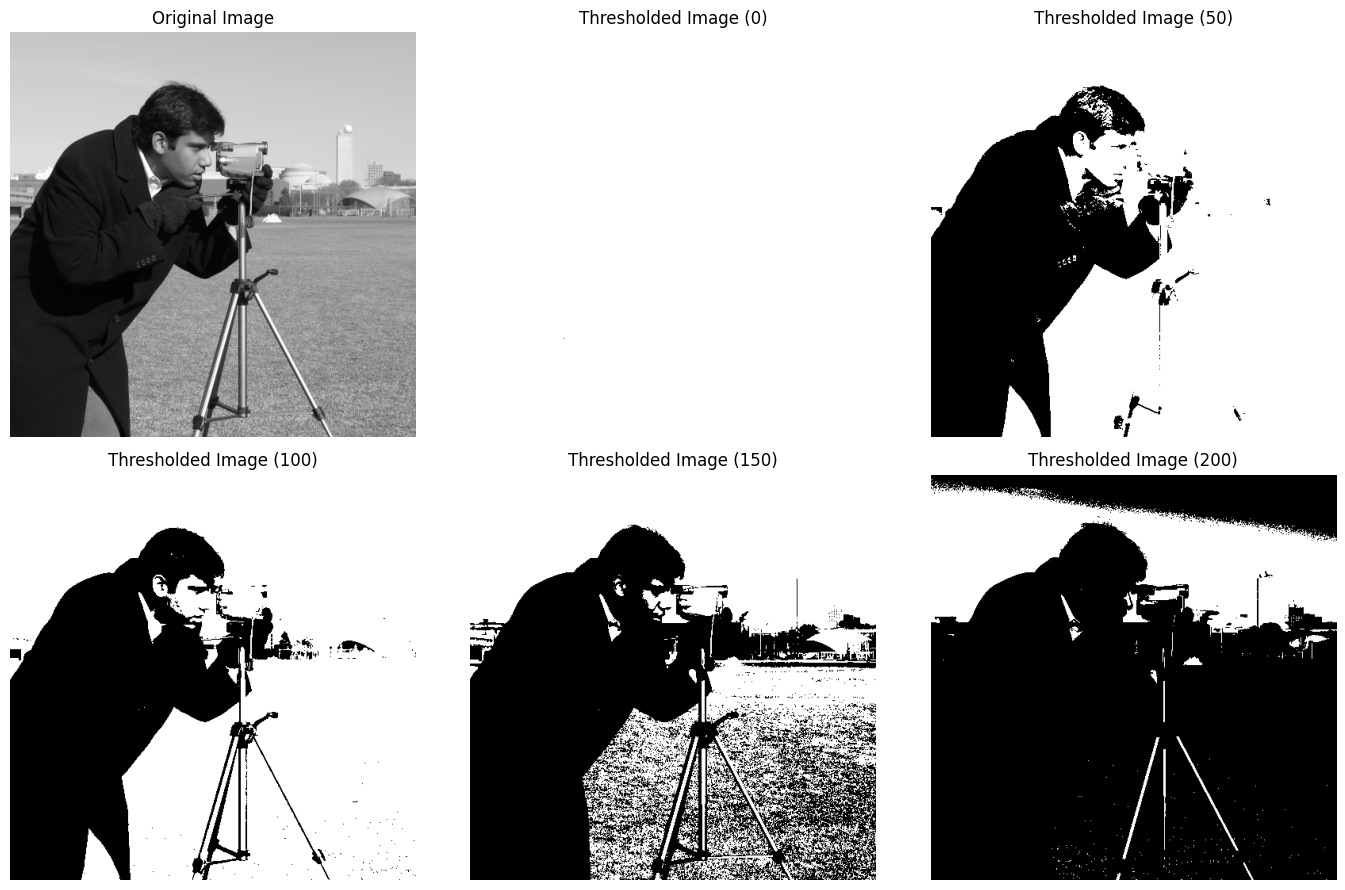

In [2]:
# Save a sample image from skimage.data to the images folder
cv2.imwrite('images/camera.png', data.camera())

# Load the image in grayscale
img = cv2.imread('images/camera.png', cv2.IMREAD_GRAYSCALE)

# Set the threshold values
threshold_values = [0, 50, 100, 150, 200]

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.ravel()
axes[0].imshow(img, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original Image')
axes[0].axis('off')

# Apply thresholding with different threshold values
for ax, threshold_value in zip(axes[1:], threshold_values):
    ret, thresh = cv2.threshold(img, threshold_value, 255, cv2.THRESH_BINARY)
    ax.imshow(thresh, cmap='gray', vmin=0, vmax=255)
    ax.set_title(f'Thresholded Image ({threshold_value})')
    ax.axis('off')

plt.tight_layout()
plt.savefig('images/task1_thresholding.png', dpi=120)
plt.show()

## Task 2: Histogram Processing
**Step 1: Load necessary libraries**

In [3]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from skimage import data, img_as_float
from skimage import exposure

**Step 2: Load moon image**

In [4]:
img = data.moon()
print('Shape:', img.shape, '| dtype:', img.dtype, '| min/max:', img.min(), img.max())

Shape: (512, 512) | dtype: uint8 | min/max: 0 255


**Step 3: Rescale intensity values to include all the intensities that fall within the 2nd and 98th percentiles (contrast stretching)**

In [5]:
# Contrast stretching
p2, p98 = np.percentile(img, (2, 98))
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))
print('p2 =', p2, ' p98 =', p98)

p2 = 78.0  p98 = 129.0


**Step 4: Display the image with its histogram of (Step 2) and (Step 3)**

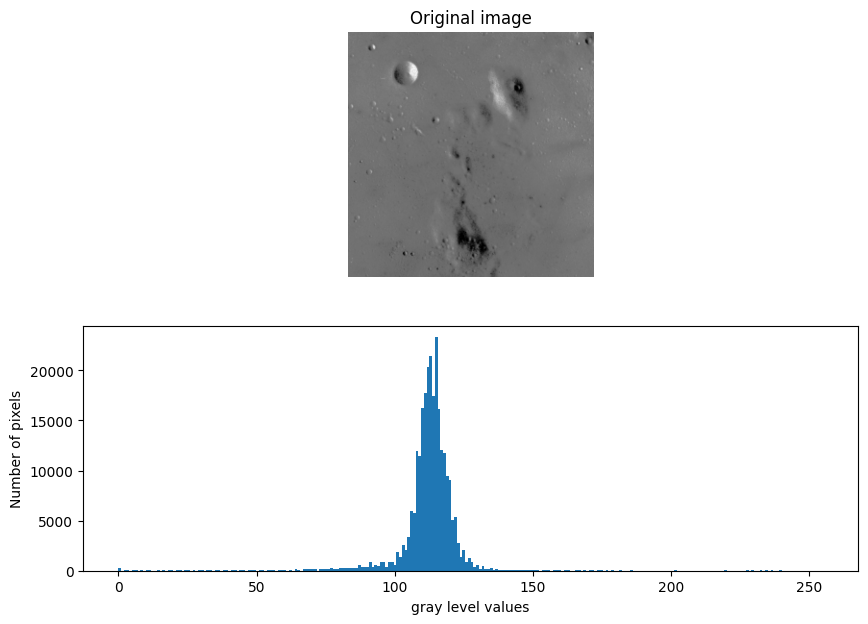

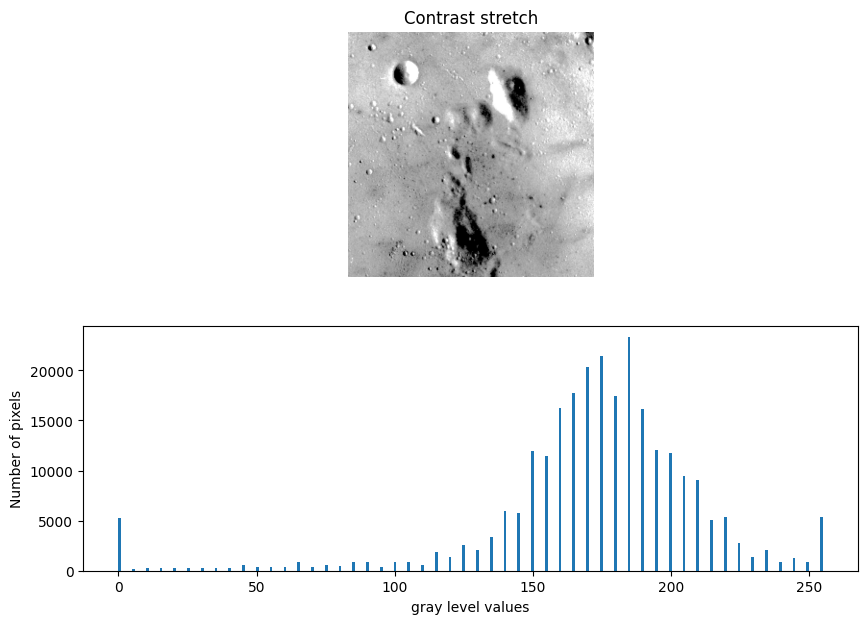

In [6]:
fig = plt.figure(figsize=(10, 7))

fig.add_subplot(2, 1, 1)
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.title('Original image')

fig.add_subplot(2, 1, 2)
plt.hist(img.flat, bins=256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.savefig('images/task2_original.png', dpi=120)
plt.show()

fig = plt.figure(figsize=(10, 7))

fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale, cmap='gray')
plt.axis('off')
plt.title('Contrast stretch')

fig.add_subplot(2, 1, 2)
plt.hist(img_rescale.flat, bins=256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.savefig('images/task2_contrast_stretch_2_98.png', dpi=120)
plt.show()

---
# Section 4 – Assessment
## Task 1: Rescale intensity (3rd and 80th percentiles) on the moon image and plot the histogram

p3 = 87.0  p80 = 118.0


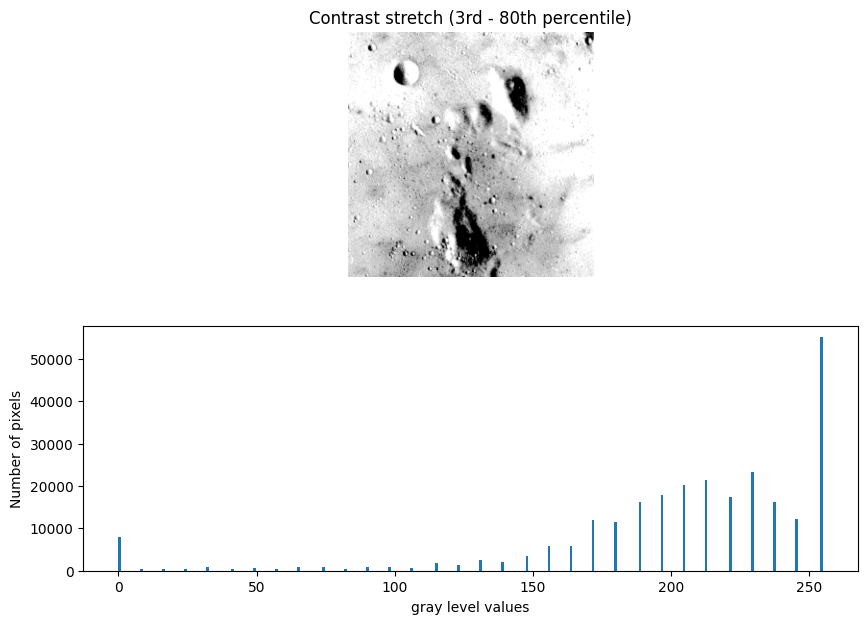

In [7]:
img = data.moon()

p3, p80 = np.percentile(img, (3, 80))
img_rescale_3_80 = exposure.rescale_intensity(img, in_range=(p3, p80))
print('p3 =', p3, ' p80 =', p80)

fig = plt.figure(figsize=(10, 7))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale_3_80, cmap='gray')
plt.axis('off')
plt.title('Contrast stretch (3rd - 80th percentile)')

fig.add_subplot(2, 1, 2)
plt.hist(img_rescale_3_80.flat, bins=256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.savefig('images/assessment1_contrast_stretch_3_80.png', dpi=120)
plt.show()

## Task 2: Histogram equalization with `exposure.equalize_hist` (moon image)

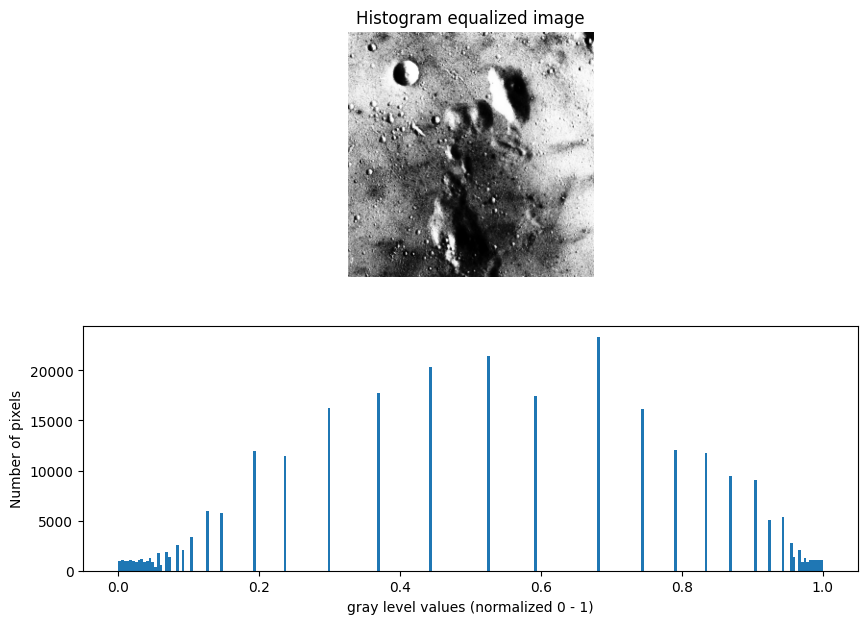

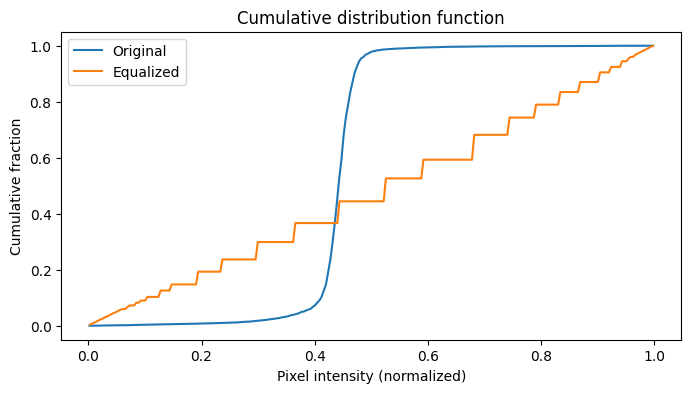

In [8]:
img = data.moon()

# Histogram equalization (flattening the histogram); output is float in [0, 1]
img_eq = exposure.equalize_hist(img)

fig = plt.figure(figsize=(10, 7))
fig.add_subplot(2, 1, 1)
plt.imshow(img_eq, cmap='gray')
plt.axis('off')
plt.title('Histogram equalized image')

fig.add_subplot(2, 1, 2)
plt.hist(img_eq.flat, bins=256, range=(0, 1))
plt.xlabel('gray level values (normalized 0 - 1)')
plt.ylabel('Number of pixels')
plt.savefig('images/assessment2_equalized.png', dpi=120)
plt.show()

# Optional: cumulative distribution before/after
fig, ax = plt.subplots(figsize=(8, 4))
for name, im in [('Original', img_as_float(img)), ('Equalized', img_eq)]:
    cdf, bins = exposure.cumulative_distribution(im)
    ax.plot(bins, cdf, label=name)
ax.set_xlabel('Pixel intensity (normalized)')
ax.set_ylabel('Cumulative fraction')
ax.set_title('Cumulative distribution function')
ax.legend()
plt.savefig('images/assessment2_cdf.png', dpi=120)
plt.show()

## Task 3: Histogram matching (rocket = reference, Chelsea = image)

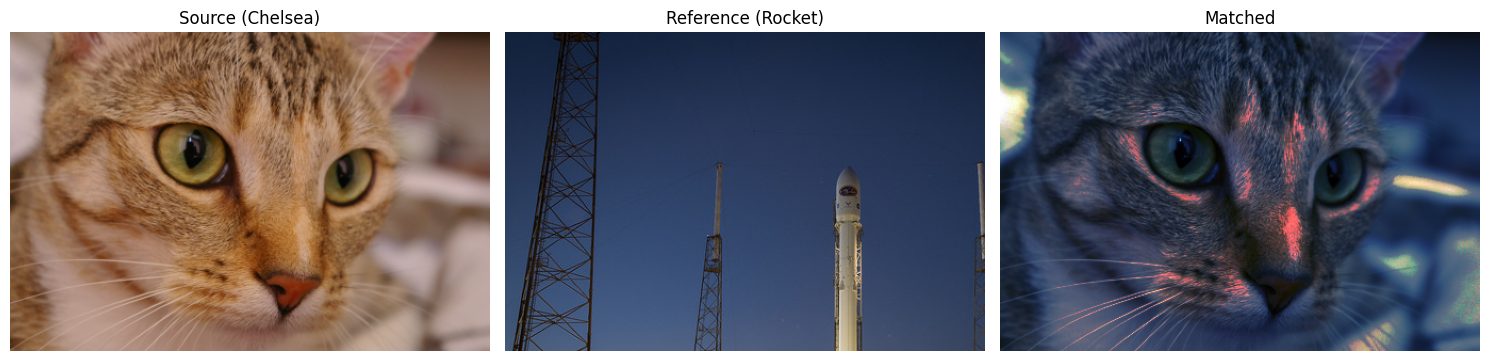

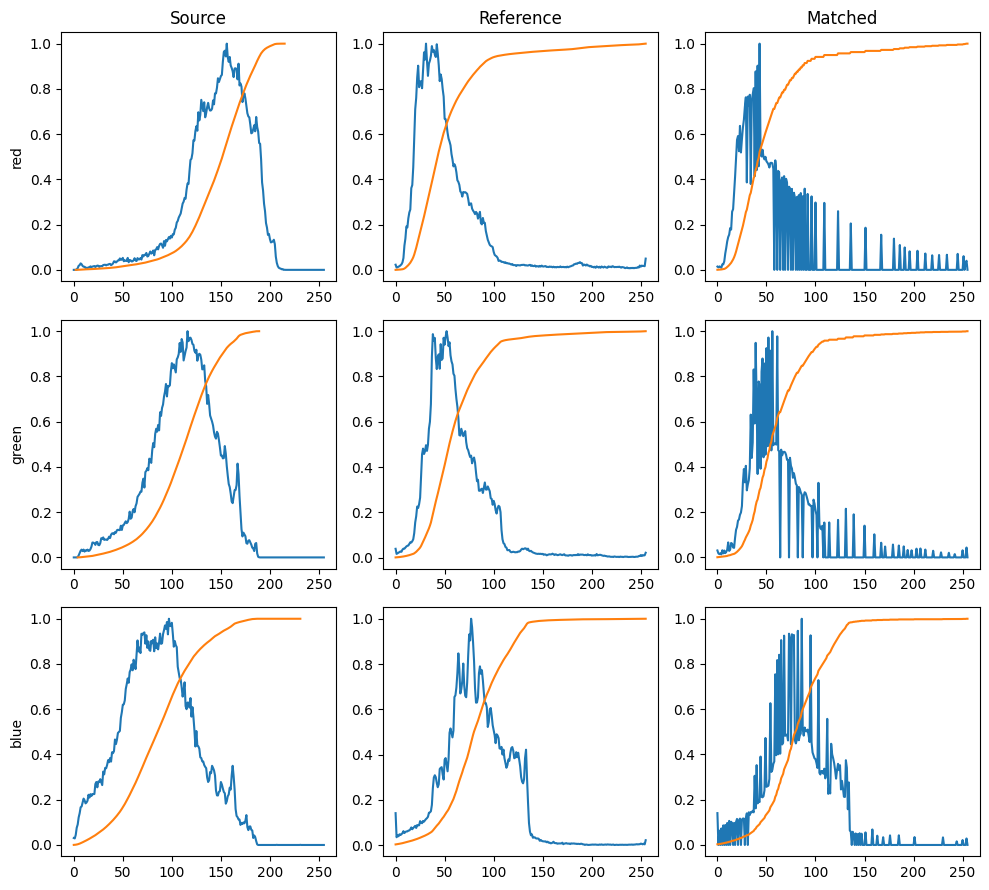

In [9]:
reference = data.rocket()    # reference image
image = data.chelsea()       # image to be matched

cv2.imwrite('images/rocket.png', cv2.cvtColor(reference, cv2.COLOR_RGB2BGR))
cv2.imwrite('images/chelsea.png', cv2.cvtColor(image, cv2.COLOR_RGB2BGR))

matched = match_histograms(image, reference, channel_axis=-1)

fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(15, 4), sharex=True, sharey=True)
for aa in (ax1, ax2, ax3):
    aa.set_axis_off()

ax1.imshow(image);     ax1.set_title('Source (Chelsea)')
ax2.imshow(reference); ax2.set_title('Reference (Rocket)')
ax3.imshow(matched);   ax3.set_title('Matched')
plt.tight_layout()
plt.savefig('images/assessment3_matching.png', dpi=120)
plt.show()

# Histograms and CDFs of each channel
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(10, 9))
for i, img_ in enumerate((image, reference, matched)):
    for c, c_color in enumerate(('red', 'green', 'blue')):
        img_hist, bins = exposure.histogram(img_[..., c], source_range='dtype')
        axes[c, i].plot(bins, img_hist / img_hist.max())
        img_cdf, bins = exposure.cumulative_distribution(img_[..., c])
        axes[c, i].plot(bins, img_cdf)
        axes[c, 0].set_ylabel(c_color)

axes[0, 0].set_title('Source')
axes[0, 1].set_title('Reference')
axes[0, 2].set_title('Matched')
plt.tight_layout()
plt.savefig('images/assessment3_histograms.png', dpi=120)
plt.show()